In [1]:
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    desc_add="clean",
)

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")


EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


In [2]:
from mreyemove.analysis.glm.atlas import fetch_atlas

atlas = fetch_atlas("schaefer500")

schaefer_groups = {}
for label in atlas.labels:
    if label in ("Background", "???"):
        continue
    # Split the label, format: "LH_Vis_1"
    parts = label.split('_')
    if len(parts) >= 3:
        hemi, network, idx = parts[1], parts[2], parts[3]
        schaefer_groups[label] = network
    else:
        schaefer_groups[label] = None  # fallback
schaefer_order = ['Vis', 'Cont', 'DorsAttn', 'Default',  'SomMot', 'SalVentAttn',  'Limbic']

[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


In [ ]:
schaefer_groups

In [ ]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"
data, _ = mrio.load_group_level_glm_data(contrast="mreyemove_S", desc_add=desc_add) 
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=500, yeo_networks=7)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    standardize_confounds=False,
    memory="nilearn_cache",
    verbose=0,
)

# Resample to atlas (TRs, n_labels)
time_series = masker.fit_transform(
    data.cope_4d,
)


In [ ]:
import numpy as np 
from nilearn import image


masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    standardize_confounds=False,
    memory="nilearn_cache",
    strategy="mean",
    detrend=False,
    verbose=0,
)

# Resample to atlas (TRs, n_labels)
cope_timeseries = masker.fit_transform(
    data.cope_4d,
)
var_timeseries = masker.transform(data.var_4d) 

out_cope = np.zeros_like(data.cope_4d.get_fdata())
out_var =  np.zeros_like(data.cope_4d.get_fdata())

atlas_data = masker.labels_img_.get_fdata()

label_arr = np.rint(masker.labels_img_.get_fdata()).astype(int)
label_ids = np.unique(label_arr)
label_ids = label_ids[label_ids != 0]          # matches *_ts column order

for col, lab in enumerate(label_ids):
    out_cope[label_arr == lab, :] = cope_timeseries[:, col]
    out_var[label_arr == lab, :] = var_timeseries[:, col]

# out_cope
cope_img =  image.new_img_like(data.cope_4d, out_cope, copy_header=True)
var_img = image.new_img_like(data.var_4d, out_var, copy_header=True)

In [4]:

import numpy as np
from nilearn import image, datasets

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"

data, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)

# Load Yeo 7 atlas and resample to cope space
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)
yeo_img = yeo.maps

yeo_resampled = image.resample_to_img(yeo_img, data.t_stat, interpolation='nearest', force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata()  # (X, Y, Z), values 1-7
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]
cope_data = data.t_stat.get_fdata()  # (X, Y, Z)
# 
# 1 - purple = visual 
# 2 - blue = somatamotor
# 3 - green = dorsal attention
# 4 - violet = vental attention
# 5 - cream = limbic 
# 6 - orange = frontoparietal 
# 7 - red = default
network_names = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']

results = {}
for net_id, net_name in enumerate(network_names, start=1):
    mask = yeo_data == net_id          # (X, Y, Z) boolean
    voxels = cope_data[mask]      # (n_voxels)
    
    results[net_name] = {
        'mean_t': voxels.mean(axis=0),           # (subjects,) mean cope per subject
        'pct_positive': (voxels > 0).mean(axis=0),  # (subjects,) fraction positive voxels
    }
    

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


In [36]:
yeo.lut["color"].values

array(['#000000', '#781286', '#4682b4', '#00760e', '#c43afa', '#dcf8a4',
       '#e69422', '#cd3e4e'], dtype=object)

In [16]:
from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn.surface import vol_to_surf
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap
import numpy as np

# Load Yeo 7 atlas and resample to cope space
surf_mesh = "fsaverage5"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness="thick")
yeo_img = yeo.maps
network_map = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
contour_cmap = ["white", "#d44be7ff", "#4682b4ff", "#00cc18ff", "#d26afbff", "#dcf8a4fc", "#e69422ff", "#e08590ff"]

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"
contrasts = ("mreyemove_W", "mreyemove_S")
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}

yeo_resampled = image.resample_to_img(yeo_img, contrast_map[contrasts[0]], interpolation="nearest", force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata() 
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]
yeo_img3d = image.new_img_like(contrast_map[contrasts[0]], yeo_data)  # yeo_data is 3D

atlas_kwargs = dict(interpolation="nearest_most_frequent")
yeo_surf = {
    "left":  vol_to_surf(yeo_img3d, fsaverage7["pial_left"],  **atlas_kwargs),
    "right": vol_to_surf(yeo_img3d, fsaverage7["pial_right"], **atlas_kwargs),
}

roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=5.0, kind="ball", n_samples=10)


for i, name in enumerate(network_map):
    if name != "Somatomotor":
        continue
    idx = i + 1

    roi_surf = {h: np.where(v == idx, idx, 0).astype(int) for h, v in yeo_surf.items()}
    roi_vol = image.new_img_like(yeo_img3d, (yeo_data == idx).astype(np.int8))

    for contrast in contrasts:
        base = contrast_map[contrast]        
        plot_img_on_surf_with_contour(
            surf_mesh=fsaverage7,
            stat_map=base,                    
            mask_img=roi_vol,              
            roi_map=roi_surf,              
            levels=[idx],
            labels=[name],
            contour_width=1,
            colors=["w"],
            vmin=-8, vmax=8,
            cmap=custom_cmap(),
            inflate=True,
            bg_on_data=True,
            legend=True,
            title=f"{name} for contrast {contrast}",
            output_file=f"/Users/zach/2025_RA/matthias/final images/networks/masked/{name}_{contrast}_fs5",
        )


[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


In [8]:
fsaverage7.keys()

dict_keys(['area_left', 'area_right', 'curv_left', 'curv_right', 'flat_left', 'flat_right', 'infl_left', 'infl_right', 'pial_left', 'pial_right', 'sphere_left', 'sphere_right', 'sulc_left', 'sulc_right', 'thick_left', 'thick_right', 'white_left', 'white_right', 'description'])

ValueError: All elements of colors need to be either a matplotlib color string or RGBA values.

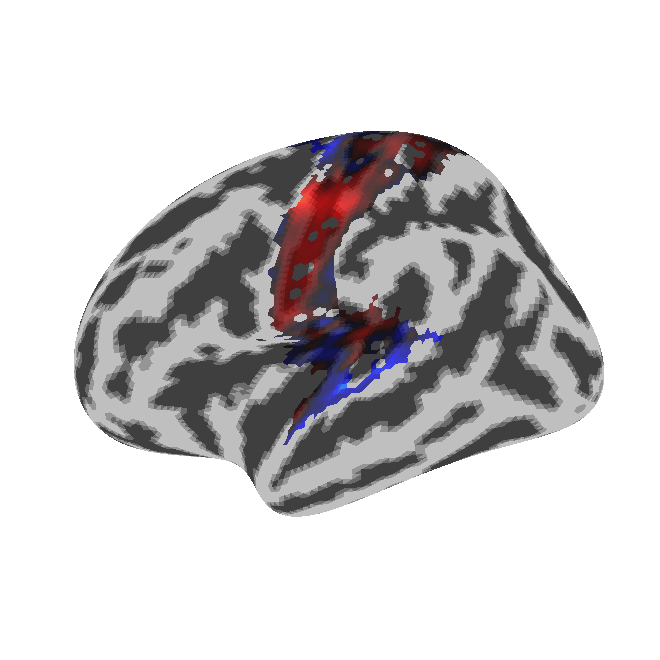

In [22]:
from mreyemove.plotting.glm_surface import nilearn_matplotlib_plot_img_on_surf_with_sig_contour
from matplotlib.colors import to_rgba, Normalize
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from nilearn._utils.helpers import compare_version
from nilearn._utils.niimg_conversions import check_niimg_3d
from nilearn.plotting.surface._matplotlib_backend import (
    _adjust_colorbar_and_data_ranges,
    _plot_surf,
    _get_ticks,
    _colorbar_from_array, _check_figure_axes_inputs,
)
from matplotlib import __version__ as mpl_version
from scipy import sparse

from matplotlib.gridspec import GridSpecFromSubplotSpec

from nilearn._utils.param_validation import check_params
from nilearn.plotting._utils import check_threshold_not_negative, save_figure_if_needed
from nilearn.plotting.surface._utils import (
    check_hemispheres,
    check_surface_plotting_inputs, DEFAULT_HEMI,
)
from nilearn.plotting.surface._utils import check_views
from nilearn.plotting.surface.surf_plotting import DATA_EXTENSIONS
from nilearn.surface.surface import (
    check_mesh_is_fsaverage,
    load_surf_data,
    load_surf_mesh, check_extensions, FREESURFER_DATA_EXTENSIONS,
)
from nilearn.surface import vol_to_surf
from nilearn import DEFAULT_DIVERGING_CMAP, image, plotting
from matplotlib import pyplot as plt
import numpy as np
from nilearn.plotting.surface._matplotlib_backend import _adjust_colorbar_and_data_ranges

for i, name in enumerate(network_map):
    if name != "Somatomotor":
        continue
    idx = i + 1

    roi_map = {h: np.where(v == idx, idx, 0).astype(int) for h, v in yeo_surf.items()}
    roi_vol = image.new_img_like(yeo_img3d, (yeo_data == idx).astype(np.int8))

    for contrast in contrasts:
        stat_map = contrast_map[contrast]            # <-- UNMASKED volume, no NaNs
        
        colors=["w"],
        cmap=custom_cmap()
        colorbar=False
        labels=[name]
        levels=[idx]
        contour_width=1
        vmin = -8
        vmax = 8
        inflate = True
        bg_on_data = True
        legend=True
        title=f"{name} for contrast {contrast}"
        output_file=f"/Users/zach/2025_RA/matthias/final images/networks/masked/{name}_{contrast}_fs5"
        
        
        
        hemispheres = ["left", "right"]
        
        views = ["lateral", "medial"]
        modes = check_views(views)
        
        stat_map = check_niimg_3d(stat_map, dtype="auto")
        surf_mesh = check_mesh_is_fsaverage(surf_mesh)
        
        mesh_prefix = "infl" if inflate else "pial"
        surf = {
            "left": surf_mesh[f"{mesh_prefix}_left"],
            "right": surf_mesh[f"{mesh_prefix}_right"],
        }
        texture = {
            "left": vol_to_surf(
                stat_map,
                surf_mesh["pial_left"],
                interpolation="linear",
                radius=3.0,
                kind="line",
                n_samples=10,
            ),
            "right": vol_to_surf(
                stat_map,
                surf_mesh["pial_right"],
                interpolation="linear",
                radius=3.0,
                kind="line",
                n_samples=10,
            ),
        }
        texture["left"][roi_surf["left"]  != idx] = np.nan   # mask in vertex space
        texture["right"][roi_surf["right"] != idx] = np.nan
        
        if roi_map is not None:
            for hemi in ("left", "right"):
                _, faces_h = load_surf_mesh(surf_mesh[f"pial_{hemi}"])
                in_roi = np.asarray(load_surf_data(roi_map[hemi])) > 0
        
        sig_roi = None
        
        # backend = get_surface_backend(DEFAULT_ENGINE)
        # get vmin and vmax for entire data (all hemis)
        _, _, vmin, vmax = _adjust_colorbar_and_data_ranges(
            image.get_data(stat_map),
            vmin=vmin,
            vmax=vmax,
            symmetric_cbar=True,
        )
        
        # mask_img=roi_vol,              
        # roi_map=roi_surf,              

        fig = nilearn_matplotlib_plot_img_on_surf_with_sig_contour(
            surf,
            surf_mesh=surf_mesh,
            stat_map=stat_map,
            sig_roi=None,
            texture=texture,
            hemis = check_hemispheres(hemispheres),
            modes=modes,
            bg_on_data=bg_on_data,
            inflate=inflate,
            output_file=output_file,
            title=title,
            colorbar=colorbar,
            vmin=vmin,
            contour_width=contour_width,
            vmax=vmax,
            symmetric_cbar=True,
            cmap=cmap,
            levels=levels,
            labels=labels,
            roi_map=roi_map,
            colors=colors,
            cbar_tick_format=None,
            legend=legend,
        )

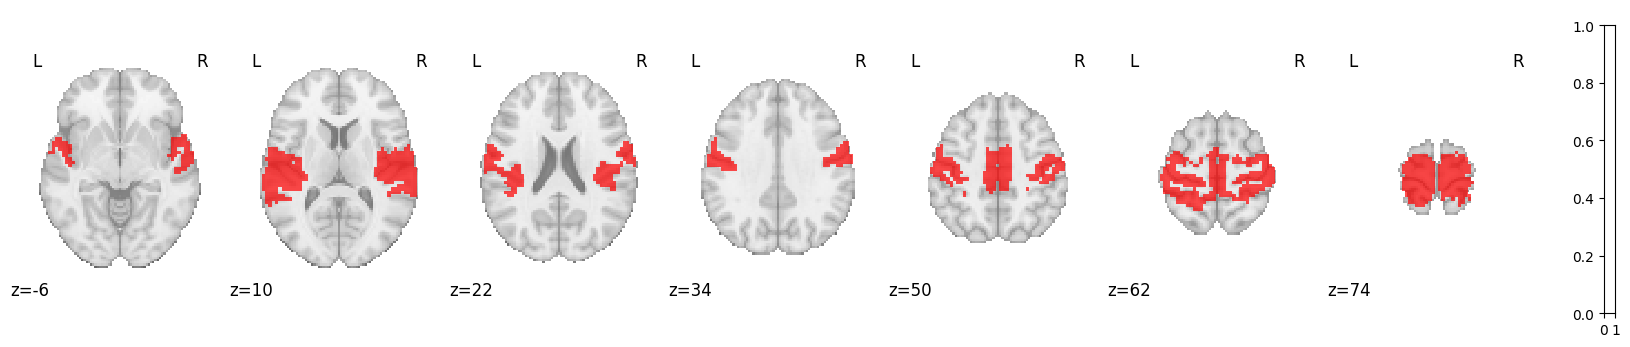

In [28]:
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)

# Project to surface with nearest-neighbor (no blurring)
labels_left = surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['left'], interpolation="nearest_most_frequent"
)
labels_right =  surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['right'], interpolation="nearest_most_frequent"
)



[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_73559/3479781269.py:14: UserWarning: Casting data from int32 to float32
  plotting.view_img(roi_vol)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_73559/3479781269.py:14: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  plotting.view_img(roi_vol)



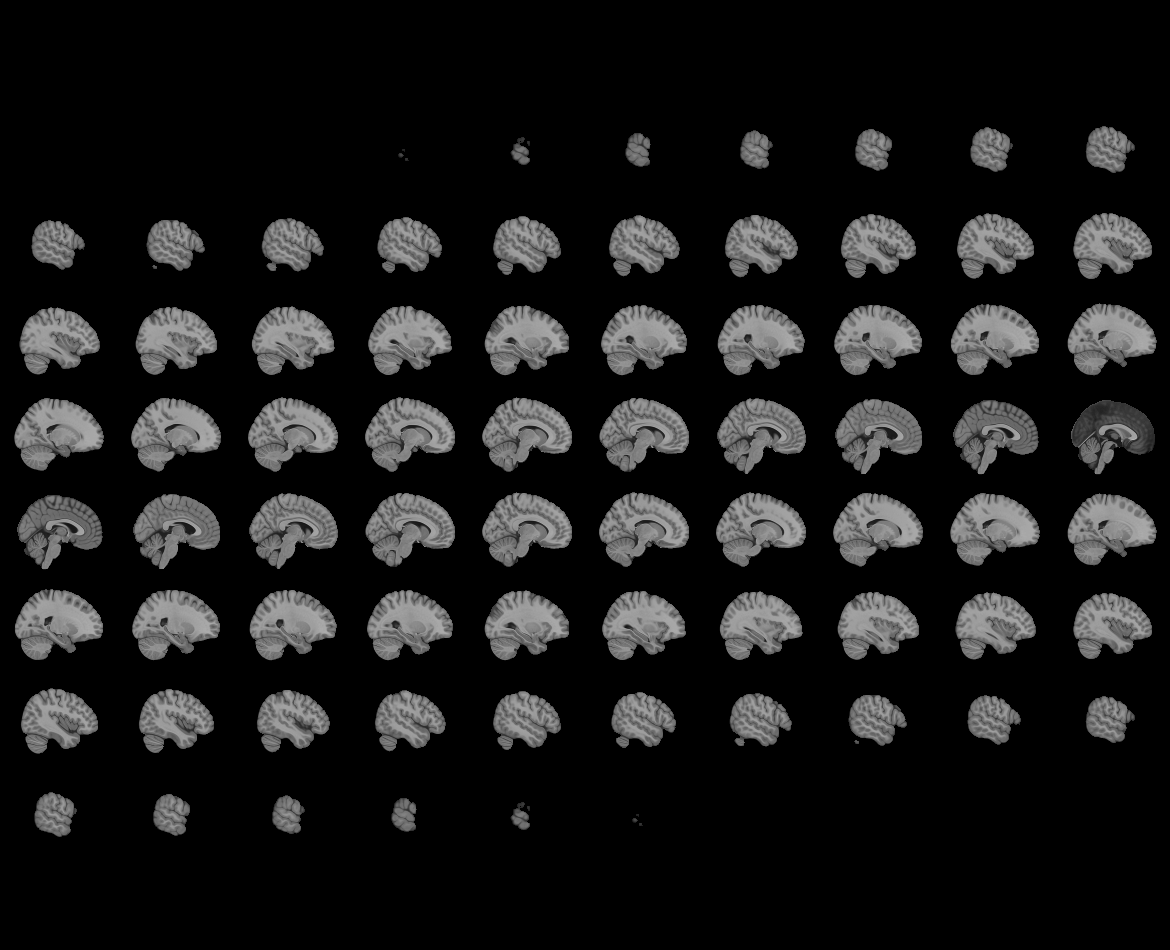
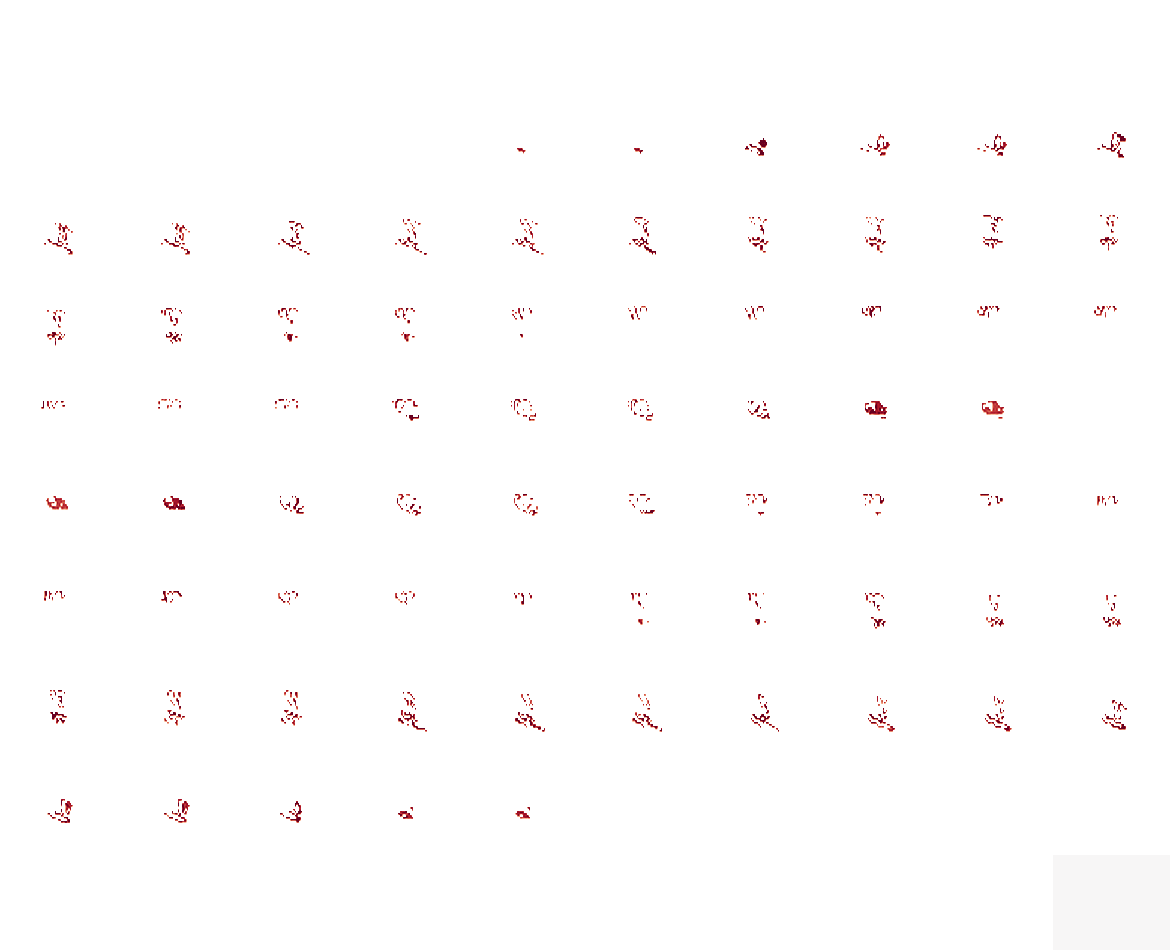

In [25]:
from nilearn import plotting

yeo = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness="thin")
yeo_img = yeo.maps
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}

yeo_resampled = image.resample_to_img(yeo_img, contrast_map[contrasts[0]], interpolation="nearest", force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata() 
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]
yeo_img3d = image.new_img_like(contrast_map[contrasts[0]], yeo_data)  # yeo_data is 3D
roi_vol = image.new_img_like(yeo_img3d, (yeo_data == 2).astype(np.int8))

plotting.view_img(roi_vol)

In [25]:
 (yeo_data == idx).astype(bool)

3386

In [33]:
from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn.surface import load_surf_mesh
from nilearn.surface import vol_to_surf
from nilearn import plotting, image
from mreyemove.plotting.glm import custom_cmap

# plotting.view_img(image.new_img_like(yeo_resampled, (yeo_data == 1).astype(float)))

# Load Yeo 7 atlas and resample to cope space
fsaverage7 = datasets.fetch_surf_fsaverage(mesh="fsaverage")
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)
yeo_img = yeo.maps

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"

contrast = "mreyemove_W"
data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)

t = data.t_stat
    
yeo_resampled = image.resample_to_img(yeo_img, t, interpolation='nearest', force_resample=True, copy_header=True)
network_map = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']

# sub_networks = {
#     "more_neg": ["Ventral Attention", "Somatomotor", "Frontoparietal"],
#     "more_pos": ["Default", "Limbic"],
#     "rest": ["Dorsal Attention", "Visual"]
# }

for tit, networks in sub_networks.items():
    roi_surf = {}
    idxs = []
    for i, name in enumerate(network_map):
        if name not in networks:
            continue
        idxs.append(i + 1)
        roi = image.new_img_like(yeo_resampled, (yeo_data == i+1).astype(float))
        left  = vol_to_surf(roi, fsaverage7["pial_left"])  >= 0.5
        right = vol_to_surf(roi, fsaverage7["pial_right"]) >= 0.5
        if "left" not in roi_surf:
            roi_surf["left"]  = np.zeros(left.shape,  dtype=int)
            roi_surf["right"] = np.zeros(right.shape, dtype=int)
        roi_surf["left"][left]   = i + 1
        roi_surf["right"][right] = i + 1
    
    for contrast in ("mreyemove_W", "mreyemove_S"):
        data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
        
        t = data.t_stat
        
        plot_img_on_surf_with_contour(
            surf_mesh="fsaverage5",
            stat_map=t,
            roi_map=roi_surf,
            inflate=True,
            levels=idxs,
            labels=networks,
            vmin=-8,
            vmax=8,
            cmap=custom_cmap(),
            bg_on_data=True,
            legend=True,
            title=f"{tit} for contrast {contrast}",
            output_file=f"/Users/zach/2025_RA/matthias/final images/networks/{tit}_{contrast}.png"
        )

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


In [ ]:
from mreyemove.plotting.glm import custom_cmap

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"

contrast = "mreyemove_W"
data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)

t = data.t_stat

median = np.median(t.get_fdata()[yeo_data == 1])
# 
# plotting.plot_img_on_surf(
#     data.t_stat,
#     inflate=True,
#     bg_on_data=True,
#     cmap=custom_cmap(),
#     vmin=-8,
#     vmax=8,
# )
# median
print(np.sum(yeo_data == 1))
print(len(t.get_fdata()[yeo_data == 1]))
print(np.prod(t.get_fdata().shape))
median

In [6]:
from nilearn.glm import threshold_stats_img


def network_summary(contrast, yeo_data, names):
    # desc_add = "clean-with-fd-clamped-original-nrem3-incl-flame"
    desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"


    data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
    z_img     = data.t_stat
    brain_mask = data.mask 
    
    # FDR + cluster extent, computed once over the brain
    thr_map, thr = threshold_stats_img(
        data.z_stat , alpha=0.05, height_control="fdr",
        cluster_threshold=20, two_sided=True, mask_img=brain_mask,
    )
    
    z, sig = z_img.get_fdata(), thr_map.get_fdata() != 0
    out = {}
    for k, name in enumerate(names, start=1):
        print(k, name)
        m = yeo_data == k
        v, s = z[m], sig[m]
        out[name] = dict(mean_z=v.mean(), median_z=np.median(v),
                         pct_sig=100 * s.mean(),
                         # rat_pos_sig=((v[s] > 0).mean() if s.any() else np.nan) / ((v[s] < 0).mean() if s.any() else np.nan),
                         rat_pos=(v > 0).mean(),#, / ((v < 0).mean() if (v < 0).mean() > 0 else 1),
                         std=v.std(),
                         )
    return out


wake_res  = network_summary("mreyemove_W",  yeo_data, network_names)
sleep_res = network_summary("mreyemove_S", yeo_data, network_names)

for net in network_names:
    w, s = wake_res[net], sleep_res[net]
    print(f"{net:12s} mean_z W={w['mean_z']:+.2f} S={s['mean_z']:+.2f} "
          f"Δ={w['mean_z']-s['mean_z']:+.2f}  %sig W={w['pct_sig']:4.1f} S={s['pct_sig']:4.1f}    + W={w['rat_pos']:4.1f} S={s['rat_pos']:4.1f}")

1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default
1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default
Visual       mean_z W=+2.43 S=+2.29 Δ=+0.15  %sig W=42.4 S=31.8    + W= 0.8 S= 0.9
Somatomotor  mean_z W=+0.07 S=-0.59 Δ=+0.66  %sig W= 2.3 S= 0.5    + W= 0.5 S= 0.2
Dorsal Attention mean_z W=+0.39 S=+0.32 Δ=+0.06  %sig W= 3.0 S= 4.5    + W= 0.5 S= 0.5
Ventral Attention mean_z W=+0.19 S=-1.05 Δ=+1.24  %sig W= 2.0 S= 8.1    + W= 0.5 S= 0.2
Limbic       mean_z W=-0.30 S=-0.08 Δ=-0.22  %sig W= 0.0 S= 0.0    + W= 0.1 S= 0.1
Frontoparietal mean_z W=-1.15 S=-1.93 Δ=+0.79  %sig W= 8.8 S=28.6    + W= 0.1 S= 0.0
Default      mean_z W=-1.32 S=-0.88 Δ=-0.44  %sig W=11.3 S= 7.4    + W= 0.1 S= 0.2



Stat: median_z
Network: Ventral Attention 
Wake: 0.16427939385175705, Sleep: -1.0077237486839294
Network: Somatomotor 
Wake: 0.11270114034414291, Sleep: -0.5753300189971924
Network: Frontoparietal 
Wake: -1.30107843875885, Sleep: -2.046178102493286
Network: Default 
Wake: -1.5740758180618286, Sleep: -0.8459910750389099
Network: Limbic 
Wake: 0.0, Sleep: 0.0
Network: Visual 
Wake: 2.6689494848251343, Sleep: 2.3755582571029663
Network: Dorsal Attention 
Wake: 0.1876019760966301, Sleep: 0.20205015689134598

Stat: pct_sig
Network: Ventral Attention 
Wake: 2.013201320132013, Sleep: 8.085808580858085
Network: Somatomotor 
Wake: 2.312800549576368, Sleep: 0.5037783375314862
Network: Frontoparietal 
Wake: 8.751431844215348, Sleep: 28.568155784650628
Network: Default 
Wake: 11.33898053202556, Sleep: 7.43052459503641
Network: Limbic 
Wake: 0.0390625, Sleep: 0.0
Network: Visual 
Wake: 42.40275526742302, Sleep: 31.82739059967585
Network: Dorsal Attention 
Wake: 3.0419373892498522, Sleep: 4.4890726

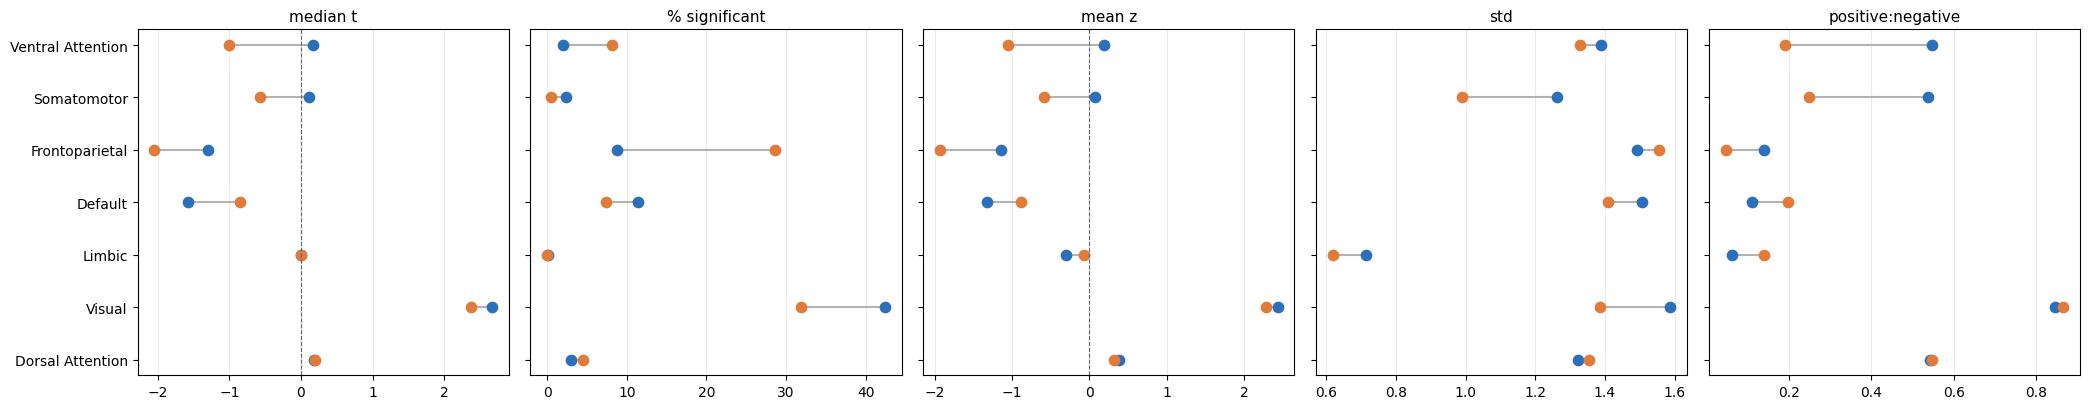

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

metrics = [
    ('median_z', 'median t', True),          # signed → zero line
    ('pct_sig', '% significant', False),
    # ('pct_pos_sig', '% positive | sig', False),
    ('mean_z', 'mean z', True),          # signed → zero line
    ("std", "std", False),
    ('rat_pos', 'positive:negative', False),
]

label_mapping = {
    
}
order = sorted(network_names, key=lambda n: abs(wake_res[n]['rat_pos'] - sleep_res[n]['rat_pos']), reverse=True)
y = np.arange(len(order))[::-1]                  # strongest at top
c_w, c_s = '#2C6FBB', '#E07B39'                  # wake, sleep

fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4.2),
                         sharey=True)

for ax, (key, label, signed) in zip(axes, metrics):
    print(f"\nStat: {key}")
    for yi, net in zip(y, order):
        w, s = wake_res[net][key], sleep_res[net][key]
        print(f"Network: {net} \nWake: {w}, Sleep: {s}")
        if np.isfinite(w) and np.isfinite(s):
            ax.plot([w, s], [yi, yi], color='0.7', lw=1.5, zorder=1)
        if np.isfinite(w):
            ax.scatter(w, yi, color=c_w, s=55, zorder=2)
        if np.isfinite(s):
            ax.scatter(s, yi, color=c_s, s=55, zorder=2)
    if signed:
        ax.axvline(0, color='0.4', lw=0.8, ls='--')
    ax.set_title(label, fontsize=11)
    ax.grid(axis='x', color='0.92'); ax.set_axisbelow(True)

axes[0].set_yticks(y); axes[0].set_yticklabels(order)
# fig.legend(handles=[Line2D([0], [0], marker='o', ls='', color=c_w, label='Wake'),
#                     Line2D([0], [0], marker='o', ls='', color=c_s, label='Sleep')],
#            loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
# fig.suptitle('Gaze-related response by Yeo-7 network — wake vs sleep (descriptive)',
#              y=1.12, fontsize=12)
fig.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/networks/diffs.svg", dpi=300)
plt.show()

In [11]:
import numpy as np
from nilearn import image, datasets
from nilearn.glm import threshold_stats_img

desc_add = "clean-with-fd-clamped-original-sleep-incl-nrem3-flame"
data, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)

z_img      = data.t_stat
brain_mask = data.mask 

# FDR + cluster extent, computed once over the brain
thr_map, thr = threshold_stats_img(
    data.z_stat , alpha=0.05, height_control="fdr",
    cluster_threshold=20, two_sided=True, mask_img=brain_mask,
)
print(f"FDR z-threshold: {thr:.3f}")

# Yeo thick_7 is (X, Y, Z, 1) -> 3D, then resample to z space
yeo = datasets.fetch_atlas_yeo_2011()
yeo_img = image.load_img(yeo.thick_7)
if yeo_img.ndim == 4:
    yeo_img = image.index_img(yeo_img, 0)
yeo_img = image.resample_to_img(
    yeo_img, z_img, interpolation="nearest",
    force_resample=True, copy_header=True,
)

yeo_data = yeo_img.get_fdata()        # (X, Y, Z)
z        = z_img.get_fdata()          # (X, Y, Z)
sig      = thr_map.get_fdata() != 0   # survived FDR + cluster extent (two-sided)

network_names = ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn',
                 'Limbic', 'Control', 'Default']

results = {}
for net_id, net_name in enumerate(network_names, start=1):
    mask = yeo_data == net_id
    v, s = z[mask], sig[mask]
    n, n_sig = v.size, int(s.sum())
    if n == 0:
        continue
    results[net_name] = {
        'n_voxels':    n,
        'mean_z':      v.mean(),
        'median_z':    float(np.median(v)),
        'iqr_z':       float(np.subtract(*np.percentile(v, [75, 25]))),
        'pct_sig':     100 * n_sig / n,                       # FDR + cluster
        'pct_pos_sig': 100 * (v[s] > 0).mean() if n_sig else np.nan,
        'pct_neg_sig': 100 * (v[s] < 0).mean() if n_sig else np.nan,
    }

FDR z-threshold: 2.724
[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_44423/1891550362.py:19: DeprecationWarning: From release >=0.13.0, instead of returning several atlas image accessible via different keys, this fetcher will return the atlas as a dictionary with a single atlas image, accessible through a 'maps' key. To suppress this warning, Please use the parameters 'n_networks' and 'thickness' to specify the exact atlas image you want.
  yeo = datasets.fetch_atlas_yeo_2011()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z_keys   = ['mean_z', 'median_z', 'iqr_z']
pct_keys = ['pct_sig', 'pct_pos_sig', 'pct_neg_sig']
labels   = z_keys + pct_keys

networks = list(results.keys())
ncols    = 4
nrows    = int(np.ceil(len(networks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = axes.ravel()

x_z   = np.arange(len(z_keys))                          # 0, 1, 2
x_pct = np.arange(len(pct_keys)) + len(z_keys) + 0.5    # 3.5, 4.5, 5.5
c_z, c_pct = '#4C72B0', '#C44E52'

for i, net in enumerate(networks):
    ax, r = axes[i], results[net]

    ax.bar(x_z, [r[k] for k in z_keys], color=c_z, width=0.8)
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_ylabel('z', color=c_z); ax.tick_params(axis='y', labelcolor=c_z)

    ax2 = ax.twinx()
    ax2.bar(x_pct, [r[k] for k in pct_keys], color=c_pct, width=0.8)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('%', color=c_pct); ax2.tick_params(axis='y', labelcolor=c_pct)

    ax.set_xlim(-0.6, 6.1)
    ax.set_xticks(np.concatenate([x_z, x_pct]))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{net}  (n={r['n_voxels']:,})", fontsize=10)

for j in range(len(networks), len(axes)):
    axes[j].axis('off')

fig.suptitle("Yeo-7 network summary — mreyemove_W  (z, FDR+cluster)", y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z_keys   = ['mean_z', 'median_z', 'iqr_z']
pct_keys = ['pct_sig', 'pct_pos_sig', 'pct_neg_sig']
labels   = z_keys + pct_keys

networks = list(results.keys())
ncols    = 4
nrows    = int(np.ceil(len(networks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = axes.ravel()

x_z   = np.arange(len(z_keys))                          # 0, 1, 2
x_pct = np.arange(len(pct_keys)) + len(z_keys) + 0.5    # 3.5, 4.5, 5.5
c_z, c_pct = '#4C72B0', '#C44E52'

for i, net in enumerate(networks):
    ax, r = axes[i], results[net]

    ax.bar(x_z, [r[k] for k in z_keys], color=c_z, width=0.8)
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_ylabel('z', color=c_z); ax.tick_params(axis='y', labelcolor=c_z)

    ax2 = ax.twinx()
    ax2.bar(x_pct, [r[k] for k in pct_keys], color=c_pct, width=0.8)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('%', color=c_pct); ax2.tick_params(axis='y', labelcolor=c_pct)

    ax.set_xlim(-0.6, 6.1)
    ax.set_xticks(np.concatenate([x_z, x_pct]))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{net}  (n={r['n_voxels']:,})", fontsize=10)

for j in range(len(networks), len(axes)):
    axes[j].axis('off')

fig.suptitle("Yeo-7 network summary — mreyemove_S  (z, FDR+cluster)", y=1.02)
fig.tight_layout()
plt.show()